## Import libraries

In [1]:
import SimpleITK as sitk # type: ignore
import os
import numpy as np # type: ignore
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import shutil # type: ignore
import seaborn as sns # type: ignore
from skimage.metrics import peak_signal_noise_ratio as psnr # type: ignore
from skimage.metrics import structural_similarity as ssim # type: ignore
from sklearn.preprocessing import MinMaxScaler # type: ignore
from sklearn.preprocessing import StandardScaler # type: ignore
from sklearn.preprocessing import MaxAbsScaler # type: ignore
from sklearn.preprocessing import RobustScaler # type: ignore

## Load Datasets

In [233]:
df_adc = pd.read_csv("../Part2/df_adc.csv").set_index("Study Instance UID")
df_hbv = pd.read_csv("../Part2/df_hbv.csv").set_index("Study Instance_UID")
df_t2w = pd.read_csv("../Part2/df_t2w.csv").set_index("Study Instance UID")

## Edge detection

### Sobel Edge detection

In [36]:
def sobel_edge(df):
    image = sitk.ReadImage(df["path"].iloc[5])
    sobel_filter = sitk.SobelEdgeDetectionImageFilter()
    edged_image = sobel_filter.Execute(image)
    edged_image_arr = sitk.GetArrayFromImage(edged_image)

    plt.figure(figsize=(5, 5))
    plt.imshow(edged_image_arr[10], cmap="gray")
    plt.title(f"sobel Edge detection")
    plt.tight_layout()
    plt.show()

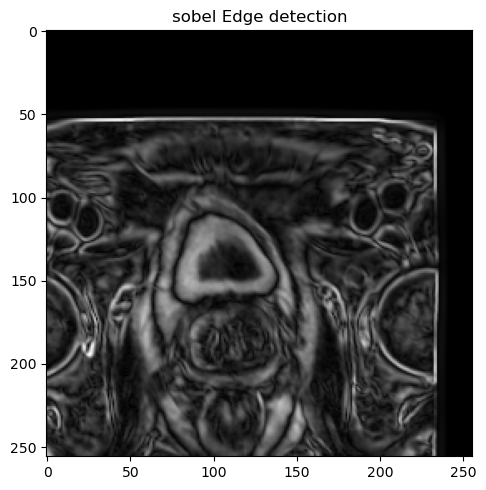

In [37]:
sobel_edge(df_t2w)

### Canny Edge detection

#### Fine tuning the canny edge detection

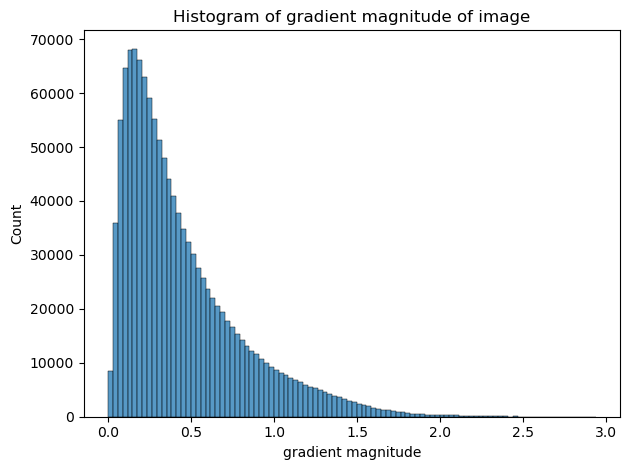

max: 2.93
min: 0.00


In [204]:
image = sitk.ReadImage(df_t2w["path"].iloc[4])
gradient_magnitude = sitk.GradientMagnitude(image)
grad_np = sitk.GetArrayFromImage(gradient_magnitude)
values = grad_np.flatten()

sns.histplot(values, bins=100)
plt.title("Histogram of gradient magnitude of image")
plt.xlabel("gradient magnitude")
plt.tight_layout()
plt.show()
print(f"max: {max(values):.2f}\nmin: {min(values):.2f}")

In [205]:
image = sitk.ReadImage(df_t2w["path"].iloc[4])
gradient_magnitude = sitk.GradientMagnitude(image)
grad_np = sitk.GetArrayFromImage(gradient_magnitude)
values = grad_np.flatten()

lower = np.percentile(values, 55)
upper = np.percentile(values, 90)

print(f"Suggested thresholds: lower={lower:.2f}, upper={upper:.2f}")

Suggested thresholds: lower=0.38, upper=0.96


In [225]:
def canny_edge(df):
    image = sitk.ReadImage(df["path"].iloc[4])
    canny_filter = sitk.CannyEdgeDetectionImageFilter()
    canny_filter.SetLowerThreshold(0.38)
    canny_filter.SetUpperThreshold(0.96)
    canny_filter.SetVariance(0)
    edged_image = canny_filter.Execute(image)
    edged_image_arr = sitk.GetArrayFromImage(edged_image)

    plt.figure(figsize=(5, 5))
    plt.imshow(edged_image_arr[10], cmap="gray")
    plt.title(f"canny Edge detection")
    plt.tight_layout()
    plt.show()

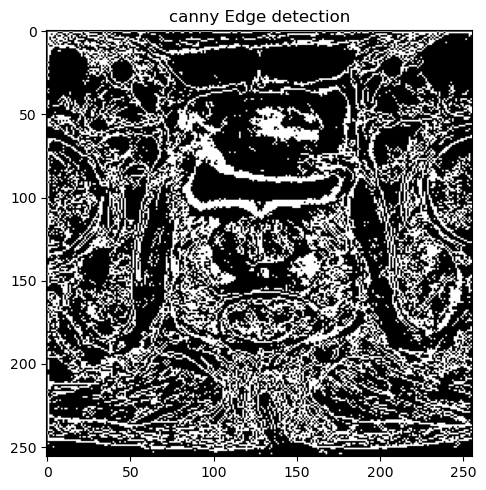

In [226]:
canny_edge(df_t2w)

#### Implementation of Canny edge detection

In [234]:
def canny_edge_filter(df):
    os.makedirs("edge_detected", exist_ok=True)
    for pic in df.index:
        image = sitk.ReadImage(df["path"][pic])
        gradient_magnitude = sitk.GradientMagnitude(image)
        grad_np = sitk.GetArrayFromImage(gradient_magnitude)
        values = grad_np.flatten()
        lower = np.percentile(values, 55)
        upper = np.percentile(values, 90)
        canny_filter = sitk.CannyEdgeDetectionImageFilter()
        canny_filter.SetLowerThreshold(lower)
        canny_filter.SetUpperThreshold(upper)
        canny_filter.SetVariance(0)
        edged_image = canny_filter.Execute(image)
        sitk.WriteImage(edged_image, f"edge_detected/{df['path'][pic].split('/')[-1]}")
        df.loc[pic, "path_edged"] = f'edge_detected/{df["path"][pic].split("/")[-1]}'
    

In [235]:
canny_edge_filter(df_t2w)

In [236]:
df_t2w.to_csv('df_t2w.csv')

## Segmentation

#### OtsuThresholding

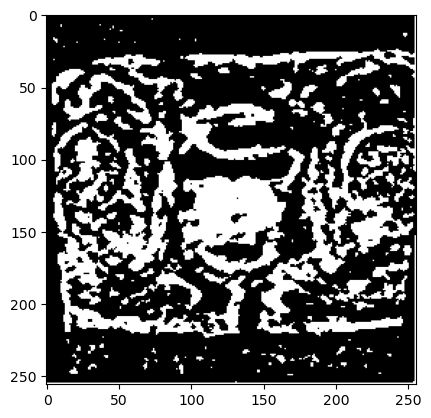

In [389]:
image = sitk.ReadImage(df_hbv["path"].iloc[4])
seg_filter = sitk.OtsuThresholdImageFilter()
seg_filter.SetInsideValue(0)
seg_filter.SetOutsideValue(1)
seg_image = seg_filter.Execute(image)
seg_array = sitk.GetArrayFromImage(seg_image)

plt.imshow(seg_array[11], cmap="gray")
plt.show()

#### WaterShed Algorithm

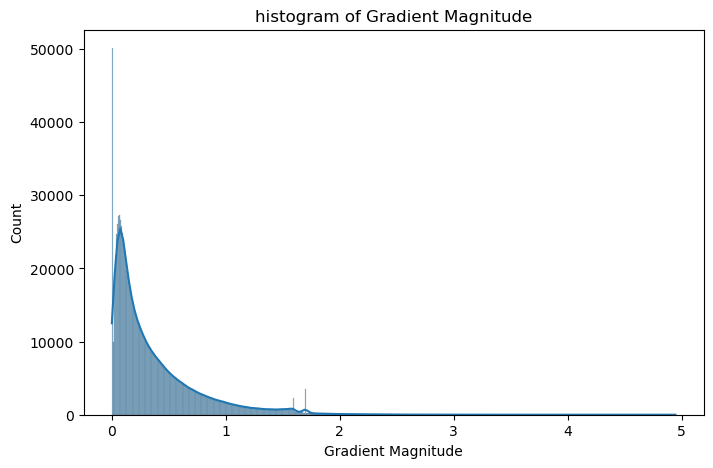

In [390]:
image = sitk.ReadImage(df_adc["path"].iloc[4])
gradient_image = sitk.GradientMagnitude(image)
image_arr = sitk.GetArrayFromImage(gradient_image)


plt.figure(figsize=(8, 5))
sns.histplot(image_arr.flatten(),  kde=True)
plt.xlabel("Gradient Magnitude")
plt.title("histogram of Gradient Magnitude")
plt.show()

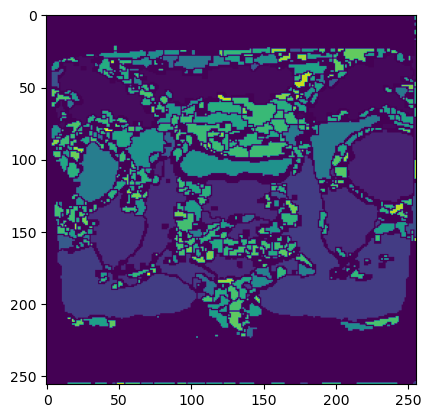

In [391]:
watershed_image = sitk.MorphologicalWatershed(gradient_image, level=0.1, fullyConnected=True)
watershed_arr = sitk.GetArrayFromImage(watershed_image)

plt.imshow(watershed_arr[11])
plt.show()

#### Implementation of watershed Algorihtm and otsu Algorithm

In [399]:
def otsu_implementation():
    os.makedirs("otsu_seg", exist_ok=True)
    for pic in df_hbv.index:
        image = sitk.ReadImage(df_hbv["path"][pic])
        seg_filter = sitk.OtsuThresholdImageFilter()
        seg_filter.SetInsideValue(0)
        seg_filter.SetOutsideValue(1)
        seg_image = seg_filter.Execute(image)
        sitk.WriteImage(seg_image, f"otsu_seg/{df_hbv['path'][pic].split('/')[-1]}")
        df_hbv.loc[pic, "otsu_path"] = f'otsu_seg/{df_hbv["path"][pic].split("/")[-1]}'

In [400]:
def watershed_implementation():
    os.makedirs("watershed_seg", exist_ok=True)
    for pic in df_adc.index:
        image = sitk.ReadImage(df_adc["path"][pic])
        gradient_image = sitk.GradientMagnitude(image)
        watershed_image = sitk.MorphologicalWatershed(gradient_image, level=0.1, fullyConnected=True)
        sitk.WriteImage(watershed_image, f"watershed_seg/{df_adc['path'][pic].split('/')[-1]}")
        df_adc.loc[pic, "watershed_seg"] = f'watershed_seg/{df_adc["path"][pic].split("/")[-1]}'

In [401]:
otsu_implementation()
watershed_implementation()

In [402]:
df_adc.to_csv("df_adc.csv")
df_hbv.to_csv("df_hbv.csv")

## GLCM

### What is GLCM?